# astrolyze — interactive tutorial 🪐

Play with a real **position–position–velocity (PPV)** cube the *house way*. This walks the same spine as [`examples/tracer_ngc628.py`](tracer_ngc628.py) — **load → moment0 → convert → plot** — then opens it up so you can poke at the objects: pull out spectra and channel maps, convert units, and watch astrolyze refuse to guess the physics. **Part 2** then organises the work as an *experiment* — ingest, a dataset manifest, an always-on run log, and a narrative.

It runs out of the box on the committed **NGC 628 CO(2–1)** cutout, so there is nothing to download. Point `$ASTROLYZE_TRACER_CUBE` at a full cube to play with real survey data instead.

> First: `pip install -e ".[notebook]"`, then `jupyter lab examples/tutorial.ipynb`.

In [1]:
%matplotlib inline
import os
import warnings

from pathlib import Path

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

# Quiet a few cosmetic library notices so the tutorial output stays readable.
warnings.filterwarnings("ignore", module="spectral_cube")
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*expm1.*")

from astrolyze.io import load
from astrolyze.core import Cube


def find_cube():
    """The committed cutout by default; the full cube if $ASTROLYZE_TRACER_CUBE is set.
    Tries a couple of relative paths so it works whether the kernel starts in the repo
    root or in examples/."""
    env = os.environ.get("ASTROLYZE_TRACER_CUBE")
    if env:
        return env
    for candidate in (
        "tests/data/ngc0628_co21_cutout.fits.gz",
        "../tests/data/ngc0628_co21_cutout.fits.gz",
    ):
        if Path(candidate).exists():
            return candidate
    raise FileNotFoundError("cutout not found — run this notebook from the repo root")


DATA = find_cube()
DATA

'../tests/data/ngc0628_co21_cutout.fits.gz'

## 1 · Load and inspect

The FITS **header is authoritative** and the load is **lazy** — the heavy array is only touched when you compute on it. `Cube` carries the physical context parsed from the header (beam, rest frequency, and — from `CTYPE3=VRAD` — the radio velocity convention).

In [2]:
cube = Cube.from_loaded(load(DATA))
cube  # <Cube NGC0628 (50, 128, 128) [K]>

<Cube NGC0628 (50, 128, 128) [K]>

In [3]:
print("object              :", cube.metadata.object)
print("telescope           :", cube.metadata.telescope)
print("rest frequency      :", cube.rest_frequency.to(u.GHz))
print("velocity convention :", cube.velocity_convention.value)
print("beam                :", cube.beam)
print("unit                :", cube.metadata.bunit)
print("complete?           :", cube.is_complete, "| missing:", cube.missing)

object              : NGC0628
telescope           : ALMA
rest frequency      : 230.538 GHz
velocity convention : radio
beam                : Beam: BMAJ=1.12125426813648 arcsec BMIN=1.12125426813648 arcsec BPA=0.0 deg
unit                : K
complete?           : True | missing: []


## 2 · The tracer spine

Velocity-integrate to **moment 0** → a `Map`, then put it in the units you want. The map supplies its *own* beam / rest frequency / convention to the unit hub, so for a brightness-temperature (K) cube `K·(m/s) → K·(km/s)` is a clean rescale with nothing to spell out. `.plot()` draws the house display: **cividis**, **WCS axes**, the **beam ellipse**, and a colorbar labelled in the data's units.

moment-0 unit: K km / s


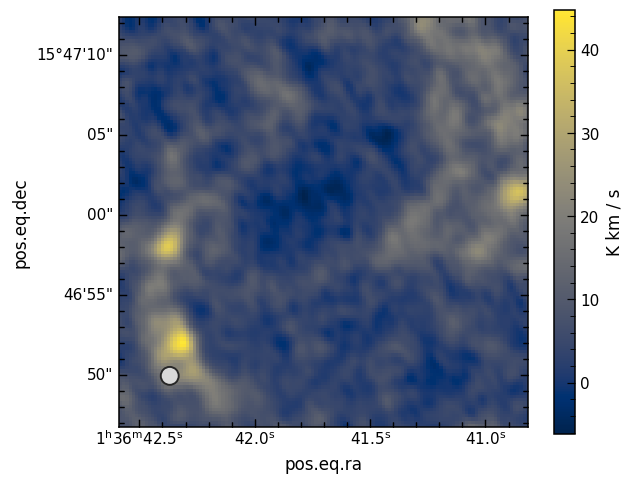

In [4]:
integrated = cube.moment0().to("K km/s")
print("moment-0 unit:", integrated.unit)
fig, ax = integrated.plot()

## 3 · Pull a spectrum from the brightest sightline

`cube[:, y, x]` transitions a `Cube` into a `Spectrum` (carrying the same context). Find the brightest pixel in the moment-0 map and look at its line profile.

brightest pixel (y, x) = (26, 19)


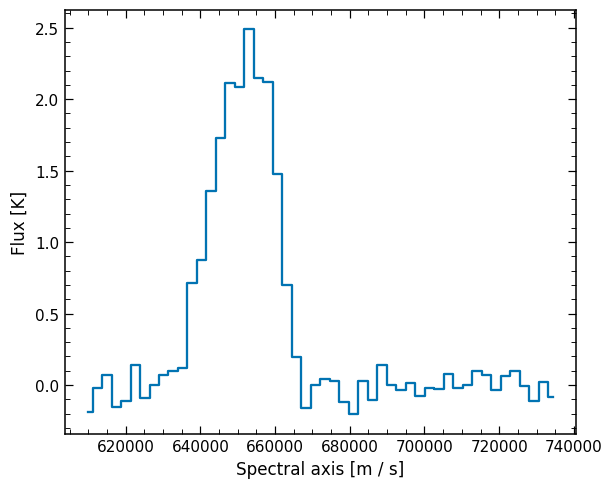

In [5]:
y, x = (
    int(i)
    for i in np.unravel_index(
        np.nanargmax(np.asarray(integrated.data.value)), integrated.shape
    )
)
print(f"brightest pixel (y, x) = ({y}, {x})")
spec = cube[:, y, x]  # -> Spectrum
fig, ax = spec.plot()

## 4 · A channel map at the line peak

`cube[k]` transitions to a `Map` — a single velocity slice, still in K. Use the spectrum above to pick the line-peak channel for that sightline.

line-peak channel = 17


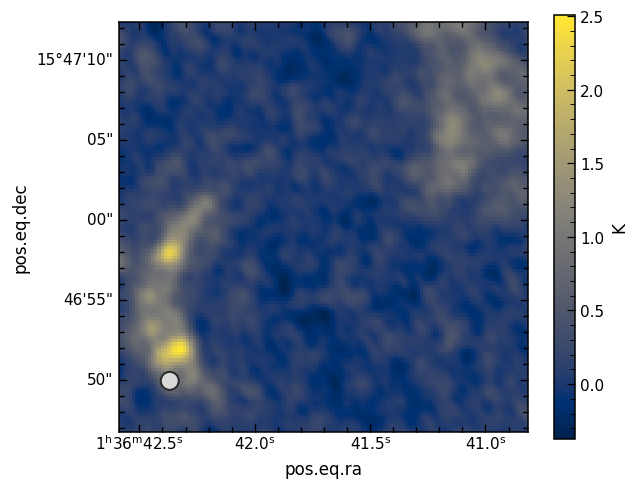

In [6]:
k = int(np.nanargmax(np.asarray(spec.flux.value)))
print(f"line-peak channel = {k}")
channel = cube[k]  # -> Map (still K)
fig, ax = channel.plot()

## 5 · Compose a multi-panel figure

The plotting engine is **free functions that accept an `ax=`**, so you build the figure and drop panels into it. Here the line-peak channel beside the integrated map, each on its own WCS. (The house style is applied *locally* — your global matplotlib settings are never touched.)

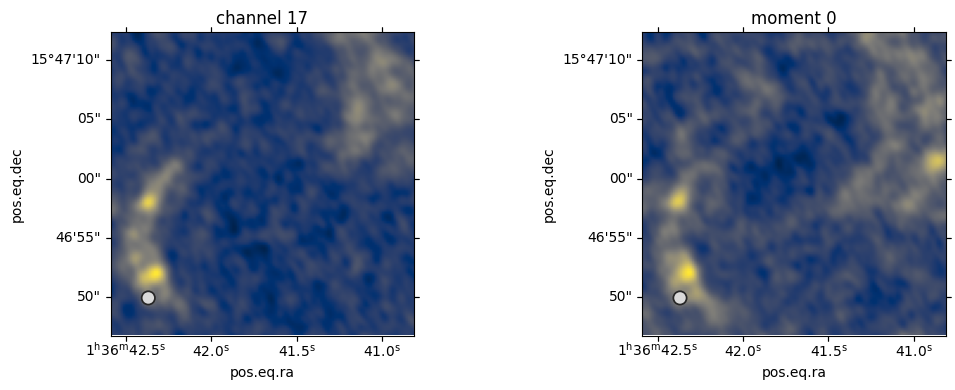

In [7]:
fig = plt.figure(figsize=(11, 4))
ax1 = fig.add_subplot(1, 2, 1, projection=channel.wcs)
ax2 = fig.add_subplot(1, 2, 2, projection=integrated.wcs)
channel.plot(ax=ax1, add_colorbar=False)
integrated.plot(ax=ax2, add_colorbar=False)
ax1.set_title(f"channel {k}")
ax2.set_title("moment 0")
fig.tight_layout()

## 6 · No silent physics

Turning a brightness-temperature channel into Jy/beam is genuinely ambiguous — **Rayleigh–Jeans** or the exact **Planck** law? astrolyze will not pick for you (ADR-0003). Ask without saying which and it raises:

In [8]:
from astrolyze.units import MissingContextError

try:
    channel.to("Jy/beam")
except MissingContextError as exc:
    print("refused:", exc)

refused: temperature_scale is required (rayleigh_jeans | planck): RJ-vs-Planck is the top silent-error trap in radio/sub-mm work, so astrolyze never assumes it


In [9]:
rj = channel.to("Jy/beam", temperature_scale="rayleigh_jeans")
planck = channel.to("Jy/beam", temperature_scale="planck")
print("Rayleigh-Jeans peak:", np.nanmax(rj.data))
print("Planck         peak:", np.nanmax(planck.data))

Rayleigh-Jeans peak: 0.1370022559242733 Jy / beam
Planck         peak: 0.007402996944035413 Jy / beam


## 7 · The same path from the shell

There is **no AI-only interface** — the CLI runs the identical spine, so an agent drives it exactly as you would. (`!` runs a shell command from the notebook.)

In [10]:
!astrolyze info {DATA}

astrolyze metadata — ngc0628_co21_cutout.fits.gz 
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ field               ┃ value                   ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ object              │ NGC0628                 │
│ telescope           │ ALMA                    │
│ species             │ —                       │
│ rest_frequency      │ 230.538 GHz             │
│ velocity_convention │ radio                   │
│ beam                │ 1.12" x 1.12" @ 0.0 deg │
│ bunit               │ K                       │
│ distance            │ —                       │
│ calibration_error   │ —                       │
│ name_tag            │ —                       │
└─────────────────────┴─────────────────────────┘
complete — has the mandatory physical context.


In [11]:
!astrolyze moment0 {DATA} -o /tmp/astrolyze_tutorial_mom0.png

wrote /tmp/astrolyze_tutorial_mom0.png  (K km / s)


---

# Part 2 · Organising the analysis as an *experiment*

Everything above worked on a bare file. The **experiment layer** gives an analysis a fixed home on disk, a gate that guarantees the physical context is present before anything is used, and an **always-on record of what ran** — so the work is portable, legible, and reproducible (ADR-0009/0010). It is the same ordinary Python/CLI whether a human or an agent drives it.

We'll scaffold a throwaway experiment in a temp directory and run the whole path: **init → ingest → analyse (run log open) → manifest → narrate**.

## 8 · Scaffold an experiment

`Experiment.init` creates the fixed skeleton (idempotent) — `data/{raw,interim,processed}`, `outputs/{figures,tables}`, `logs/`, and a `config.toml`. **`raw/` is sacred**: astrolyze never writes to or renames anything inside it.

In [12]:
import shutil
import tempfile

from astropy.io import fits

from astrolyze.experiment import Experiment, Manifest, RunLog, ingest, narrate
from astrolyze.io import save

STUDY = Path(tempfile.mkdtemp(prefix="astrolyze-tutorial-"))
exp = Experiment.init(STUDY)

print("experiment root:", exp.root, "\n")
for sub in (
    "data/raw",
    "data/interim",
    "data/processed",
    "outputs/figures",
    "outputs/tables",
    "logs",
    "config.toml",
):
    print("  ", "OK" if (exp.root / sub).exists() else "--", sub)

experiment root: /tmp/claude-1000/astrolyze-tutorial-l68qi350 

   OK data/raw
   OK data/interim
   OK data/processed
   OK outputs/figures
   OK outputs/tables
   OK logs
   OK config.toml


## 9 · Merciless ingest

Put data in `raw/`, then `ingest` validates every file's header against the schema and **registers only what is complete** — naming the exact missing fields for anything it rejects. Nothing incomplete ever reaches the manifest, so a *registered* dataset is always safe to compute on. (`raw/` stays sacred, and ingest reads **only headers**, never the multi-GB cube body.)

In [13]:
# raw/ is sacred — we put files in; astrolyze only ever reads them.
shutil.copy2(DATA, exp.raw / Path(DATA).name)

# ...and a deliberately-incomplete cube (no rest frequency, no velocity convention)
# so we can watch the merciless gate bite.
incomplete = fits.Header()
incomplete["OBJECT"], incomplete["BUNIT"] = "NGC0628", "Jy/beam"
fits.writeto(exp.raw / "archival_incomplete.fits", np.zeros((8, 8)), incomplete)

report = ingest(exp)
print(f"{report.n_accepted} accepted, {report.n_rejected} rejected\n")
for a in report.accepted:
    print("  OK accepted:", a.source_path)
for r in report.rejected:
    print("  XX rejected:", r.source_path, "- missing", r.missing)

1 accepted, 1 rejected

  OK accepted: data/raw/ngc0628_co21_cutout.fits.gz
  XX rejected: data/raw/archival_incomplete.fits - missing ['rest_frequency', 'velocity_convention']


## 10 · The dataset manifest

Ingest **generates** a DB-backed manifest (sqlite, one file inside the experiment) — one row per dataset carrying its identity and full provenance, queryable by object / species / … instead of grepping filenames. It is never hand-edited; re-ingesting keeps it in sync.

In [14]:
manifest = Manifest.for_experiment(exp)
for rec in manifest.all():
    m = rec.metadata
    rest = m.rest_frequency.to(u.GHz) if m.rest_frequency is not None else None
    print(f"#{rec.id}  {rec.source_path}")
    print(f"      object={m.object}  species={m.species}  rest={rest}")

hits = [r.source_path for r in manifest.query(object="NGC0628")]
print("\nquery(object='NGC0628') ->", hits)

#1  data/raw/ngc0628_co21_cutout.fits.gz
      object=NGC0628  species=None  rest=230.538 GHz

query(object='NGC0628') -> ['data/raw/ngc0628_co21_cutout.fits.gz']


## 11 · The always-on run log

Open a run and **every** operation appends a record to `logs/` automatically — load, moment, `.to`, save, plot — so *what ran* is captured without you remembering to log it. Outside a run the seam is a silent no-op (everything in Part 1 ran with no log). Records are append-only JSONL, one run per file.

run 20260604T144345_681918-62adaa6c -> logs/run-20260604T144345_681918-62adaa6c.jsonl 

  load    params={}  outputs=[]
  moment  params={'order': 0, 'axis': 0}  outputs=[]
  to      params={'unit': 'K km/s', 'temperature_scale': None}  outputs=[]
  save    params={'extension': 'fits'}  outputs=['/tmp/claude-1000/astrolyze-tutorial-l68qi350/data/processed/NGC0628_ALMA_unknown_Kkms_1.12.fits']
  plot    params={'viz_function': 'plot_map'}  outputs=[]


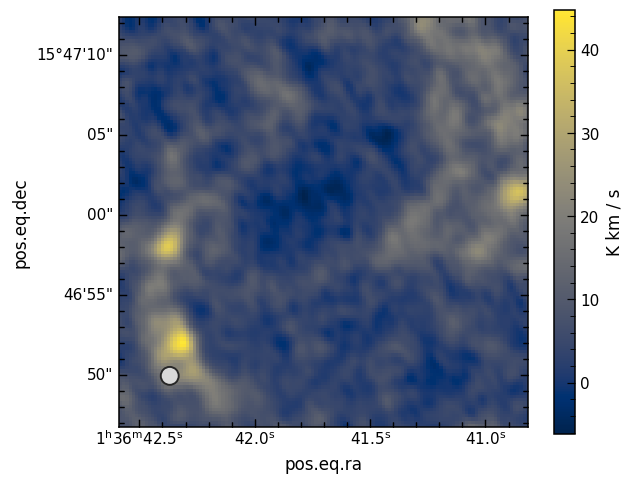

In [15]:
raw_cube = exp.raw / Path(DATA).name
with RunLog.open(exp) as run:
    cube = Cube.from_loaded(load(raw_cube))
    mom0 = cube.moment0().to("K km/s")
    derived = save(np.asarray(mom0.data.value), mom0.metadata, exp.processed)
    fig, _ = mom0.plot()
    fig.savefig(exp.figures / "ngc0628_co21_moment0.png", bbox_inches="tight", dpi=150)

print("run", run.run_id, "->", run.path.relative_to(exp.root), "\n")
for rec in run.entries():
    print(f"  {rec['op']:7} params={rec['params']}  outputs={rec['outputs']}")

## 12 · The narrative offer

The run log records *what* ran; the **narrative** is the human *why / what I found / what it means*. It is **offered, never enforced** — `narrate` scaffolds a markdown note beside the run, pre-filled with the real run-log artifacts and empty prose sections, and re-running it never clobbers what you've written. Keep any account checkable against the run log it points at (ADR-0013).

In [16]:
note = narrate(exp)
print("note:", note.relative_to(exp.root), "\n")
print(note.read_text())

note: logs/run-20260604T144345_681918-62adaa6c.md 

# Narrative — run-20260604T144345_681918-62adaa6c

- **Experiment:** `/tmp/claude-1000/astrolyze-tutorial-l68qi350`
- **Run log:** [`run-20260604T144345_681918-62adaa6c.jsonl`](run-20260604T144345_681918-62adaa6c.jsonl) — the machine record of what actually ran
- **Operations recorded:** load → moment → to → save → plot
- **Output artifacts:** `data/processed/NGC0628_ALMA_unknown_Kkms_1.12.fits`

<!--
This note is an *offer*, never a requirement (ADR-0010). Write the scientific "why / what I
found / what it means" below when it is genuinely worth writing — astrolyze never mandates it.
Keep your account checkable: point at the real run-log / figure artifacts referenced above (the
run log is the machine record of what actually ran). Delete this comment when you start.
-->

## Why


## What I found


## What it means



## 13 · …and all of it from the shell

The experiment path has the same CLI surface — an agent reaches for it exactly as you would. Re-running `narrate` here just **opens** the note it already wrote (idempotent).

In [17]:
!astrolyze manifest list {exp.root}

        dataset manifest — /tmp/claude-1000/astrolyze-tutorial-l68qi350         
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━┓
┃ id ┃ dataset             ┃ object  ┃ telescope ┃ species ┃ rest freq   ┃ doi ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━┩
│  1 │ data/raw/ngc0628_c… │ NGC0628 │ ALMA      │ —       │ 230.538 GHz │ —   │
└────┴─────────────────────┴─────────┴───────────┴─────────┴─────────────┴─────┘


In [18]:
!astrolyze narrate {exp.root}

opened existing narrative note: 
/tmp/claude-1000/astrolyze-tutorial-l68qi350/logs/run-20260604T144345_681918-62a
daa6c.md
optional, never required — write the why/what-you-found in your editor; keep it 
checkable against the run log it references.


---

# Part 3 · The objects, opened up

Part 1 walked the spine and Part 2 organised it as an experiment. This part pokes at four newer capabilities of the core objects — and they all sing the same tune: **every operation returns a first-class, context-carrying object, and the library flags or refuses rather than guessing the physics.**

- **14 — format-neutral metadata** projects the schema to a JSON-able dict that round-trips, so the physical context can ride on a backend that has no FITS header.
- **15 — coordinate arrays + validity** turn the parsed axes into `Quantity` arrays and a *where-the-data-is-real* mask that travels through a slice.
- **16 — typed insufficiency** lets you *ask* "what would I need to do X?" and get a structured answer back — no exception, no guess.
- **17 — guarded matching** smooths beams and bins channels, and **refuses** the lossy-inverse (deconvolve / up-sample) it cannot honestly do.

We rebuild a fresh `cube` here (Part 2 reused the name for its run-logged work).

In [19]:
cube = Cube.from_loaded(load(DATA))
cube

<Cube NGC0628 (50, 128, 128) [K]>

## 14 · Format-neutral metadata I/O

The FITS header is authoritative, but the physical context is not *trapped* in FITS. `Metadata.to_attrs()` projects the schema onto a plain, **JSON-serializable** dict — `Quantity` becomes `{"value", "unit"}`, the beam becomes its three angles, the convention and unit become strings. `Metadata.from_attrs()` is the exact inverse, so the context round-trips through anything that can carry a dict (`from_attrs(to_attrs(m)) == m`). Absent fields are simply omitted, so a partial schema projects without inventing context (ADR-0006).

The load seam itself is backend-ready: `LoadedData` carries an **optional** live `header` *and* a verbatim `header_string`. The WCS reconstructs from that string alone — `WCS(fits.Header.fromstring(...))` — so the exact astrometry travels even where there is no live `fits.Header` to hand.

In [20]:
import json

from astropy.io import fits
from astropy.wcs import WCS

from astrolyze.io import LoadedData, Metadata

loaded = load(DATA)
print("loaded is LoadedData :", isinstance(loaded, LoadedData))
print("live header present  :", loaded.header is not None)
print("header_string chars  :", len(loaded.header_string))

# Project the schema -> JSON -> back, and confirm the round-trip is exact.
attrs = loaded.metadata.to_attrs()
print("\nto_attrs() ->", json.dumps(attrs, indent=2))

restored = Metadata.from_attrs(json.loads(json.dumps(attrs)))
print("\nround-trip equal?    :", restored == loaded.metadata)
print("restored rest freq   :", restored.rest_frequency.to(u.GHz))

# The verbatim header string reconstructs the exact WCS with no live fits.Header.
rebuilt = WCS(fits.Header.fromstring(loaded.header_string))
print(
    "\nWCS from string only :",
    rebuilt.naxis,
    "axes; spectral CTYPE =",
    rebuilt.wcs.ctype[2],
)

loaded is LoadedData : True
live header present  : True
header_string chars  : 5760

to_attrs() -> {
  "schema": 1,
  "object": "NGC0628",
  "telescope": "ALMA",
  "rest_frequency": {
    "value": 230538000000.0,
    "unit": "Hz"
  },
  "velocity_convention": "radio",
  "beam": {
    "bmaj": {
      "value": 0.0003114595189268,
      "unit": "deg"
    },
    "bmin": {
      "value": 0.0003114595189268,
      "unit": "deg"
    },
    "bpa": {
      "value": 0.0,
      "unit": "deg"
    }
  },
  "bunit": "K"
}

round-trip equal?    : True
restored rest freq   : 230.538 GHz

WCS from string only : 3 axes; spectral CTYPE = VRAD


## 15 · Coordinate arrays and where the data is real

`cube.coordinates` surfaces the axes the WCS already parsed as first-class `AxisCoordinates` — never bare arrays. Each field is a `Quantity` carrying its own unit: the **authoritative** absolute `frequency` per channel, the per-line `delta_v` *derived from it* under the cube's own convention + rest frequency (not guessed — ask for it without that context and it raises, ADR-0003), the sky `longitude`/`latitude` maps, and the celestial `pixel_scale`. A `Map` exposes only the sky/pixel subset and a `Spectrum` only the spectral subset; the absent fields are simply `None`.

`cube.validity` answers *where is the data real?* — the values with blanked / edge / outside-coverage voxels as `NaN`, plus a boolean finite-data `mask`. Because the mask is read from the same array, it **travels with the data through a slice**: the mask of a subcube equals the slice of the mask, for free.

In [21]:
coords = cube.coordinates
print(
    "frequency   :",
    coords.frequency.shape,
    "-> first channel",
    coords.frequency[0].to(u.GHz),
)
print(
    "delta_v     :",
    coords.delta_v.shape,
    "-> first channel",
    coords.delta_v[0].to(u.km / u.s),
)
print("longitude   :", coords.longitude.shape, coords.longitude.unit)
print("latitude    :", coords.latitude.shape, coords.latitude.unit)
print("pixel_scale :", coords.pixel_scale.to(u.arcsec))

# A Map carries only the sky/pixel subset; its spectral fields are None.
channel_coords = cube[0].coordinates
print(
    "\nMap.coordinates.frequency :",
    channel_coords.frequency,
    "(no spectral axis on a 2D map)",
)
print("Map.coordinates.pixel_scale:", channel_coords.pixel_scale.to(u.arcsec))

frequency   : (50,) -> first channel 230.06901445485997 GHz
delta_v     : (50,) -> first channel 609.87051741579 km / s
longitude   : (128, 128) deg
latitude    : (128, 128) deg
pixel_scale : [0.2 0.2] arcsec

Map.coordinates.frequency : None (no spectral axis on a 2D map)
Map.coordinates.pixel_scale: [0.2 0.2] arcsec


In [22]:
# Blank a corner of every channel so the validity mask has something to say (the committed
# cutout is fully finite). We never touch the file — just build a cube from a blanked copy.
blanked_data = np.asarray(loaded.data, dtype=float).copy()
blanked_data[:, :8, :8] = np.nan
blanked = Cube.from_loaded(
    LoadedData(
        data=blanked_data,
        wcs=loaded.wcs,
        metadata=loaded.metadata,
        path=loaded.path,
        header_string=loaded.header_string,
        header=loaded.header,
    )
)

v = blanked.validity
print("validity.data unit :", v.data.unit, "| mask dtype:", v.mask.dtype)
print(
    "finite voxels      :", int(v.mask.sum()), "of", v.mask.size, "(NaN where blanked)"
)

# The mask travels through a subcube slice: mask-of-a-slice == slice-of-the-mask.
sub = blanked[:, :32, :32]
print("\nsubcube            :", sub.shape)
print(
    "mask travels?      :", bool(np.array_equal(sub.validity.mask, v.mask[:, :32, :32]))
)
print(
    "blanked corner stays invalid in the slice:",
    bool((~sub.validity.mask[:, :8, :8]).all()),
)

validity.data unit : K | mask dtype: bool
finite voxels      : 816000 of 819200 (NaN where blanked)

subcube            : (50, 32, 32)
mask travels?      : True
blanked corner stays invalid in the slice: True


## 16 · Ask before you leap — typed insufficiency

Section 6 showed the unit hub *raising* when the physics is ambiguous. Sometimes you would rather **ask first** and branch on the answer instead of catching an exception. `cube.can_convert_to(unit)` is the non-raising probe: it returns an `Insufficiency` — an ordered list of named `ContextGap`s, each saying *what* is missing and *why* — and it is **falsy when satisfied**, so `if cube.can_convert_to("K"): ...` reads naturally (issue #29, ADR-0013).

The gaps are decided from the *requested conversion*, not from a fixed checklist. Converting our K cube to `Jy/beam` reports `calibration_scale`: the cube has its rest frequency and beam, but the Rayleigh–Jeans-vs-Planck scale is a decision the object structurally *cannot* hold, so it is always named here — the same no-silent-physics rule as section 6, now as a value you can inspect.

And the raise and the probe speak the **same language**: `MissingContextError` (raised by `require_complete()` / `Metadata.ensure_complete()` when mandatory context is absent) carries that very `Insufficiency` on `.insufficiency`, so the descriptor is available whether you probed or got raised at.

In [23]:
from dataclasses import replace

from astrolyze.units import MissingContextError

# Satisfied: a no-op K -> K needs nothing, so the descriptor is empty (and falsy).
clean = cube.can_convert_to("K")
print(
    "can_convert_to('K')      satisfied?",
    clean.is_satisfied,
    "| truthy gaps?",
    bool(clean),
)

# Insufficient: K -> Jy/beam names the gap the object cannot itself supply.
gaps = cube.can_convert_to("Jy/beam")
print("can_convert_to('Jy/beam') gaps   :", gaps.names)
for g in gaps:
    print(f"   - {g.name}: {g.reason}")
    print(f"     how to supply: {g.how_to_supply}")

# Strip the mandatory context and the probe names more gaps — still without raising.
incomplete = Cube(
    cube._sc, replace(cube.metadata, rest_frequency=None, velocity_convention=None)
)
print("\nincomplete probe to 'K km/s':", incomplete.can_convert_to("K km/s").names)

# The raise carries the SAME descriptor type — read the gaps without parsing the message.
try:
    incomplete.require_complete()
except MissingContextError as exc:
    print("MissingContextError.insufficiency names:", exc.insufficiency.names)
    print(
        "same Insufficiency value object?       :",
        type(exc.insufficiency) is type(clean),
    )

can_convert_to('K')      satisfied? True | truthy gaps? False
can_convert_to('Jy/beam') gaps   : ['calibration_scale']
   - calibration_scale: the brightness-temperature calibration scale (T_mb | T_A* | T_R*, i.e. Rayleigh-Jeans vs Planck) is genuinely ambiguous and the top silent-error trap in radio/sub-mm work, so astrolyze never picks one
     how to supply: state the scale on the conversion (e.g. temperature_scale='rayleigh_jeans' or 'planck')

incomplete probe to 'K km/s': ['rest_frequency', 'calibration_scale']
MissingContextError.insufficiency names: ['rest_frequency', 'velocity_convention']
same Insufficiency value object?       : True


## 17 · Matching resolution — and refusing the impossible

To compare two datasets you bring them to a common resolution. `convolve_to_beam(beam)` smooths the cube spatially to a **larger** beam; `spectral_bin(factor)` coarsens the spectral axis; `match_to(other)` finds the smallest common beam both cubes can be *smoothed* to and convolves each to it. Each returns a first-class `Cube` carrying the new, larger beam as context (ADR-0004) — the maths is delegated to `spectral-cube` / `radio_beam`; astrolyze adds the guard and the context carry.

The guard is the point. These operations only ever **lose** resolution. Asking for the lossy inverse — deconvolving to a *smaller* beam, or up-sampling to *finer* channels — would invent structure the data never contained, so astrolyze raises `LossyDirectionError` rather than silently super-resolving (no silent physics, ADR-0003).

In [24]:
import contextlib
import io

import radio_beam

from astrolyze.core.cube import LossyDirectionError

print("native beam   :", cube.beam.major.to(u.arcsec))

# Smooth spatially to a larger beam -> a new Cube carrying the larger beam.
target_beam = radio_beam.Beam(major=3 * u.arcsec, minor=3 * u.arcsec, pa=0 * u.deg)
smoothed = cube.convolve_to_beam(target_beam)
print('convolve_to_beam(3") ->', smoothed.beam.major.to(u.arcsec))

# Coarsen the spectral axis (the progress bar is cosmetic; keep the output clean).
with contextlib.redirect_stderr(io.StringIO()):
    binned = cube.spectral_bin(2)
print("spectral_bin(2)      -> channels", cube.shape[0], "->", binned.shape[0])

# match_to: bring two cubes to their smallest common beam (neither is super-resolved).
other = Cube(
    cube._sc,
    replace(cube.metadata, beam=radio_beam.Beam(2 * u.arcsec, 2 * u.arcsec, 0 * u.deg)),
)
matched_self, matched_other = cube.match_to(other)
print(
    "match_to common beam ->",
    matched_self.beam.major.to(u.arcsec),
    "/",
    matched_other.beam.major.to(u.arcsec),
)

# The guard: the lossy inverse is refused, never silently super-resolved.
smaller = radio_beam.Beam(major=0.5 * u.arcsec, minor=0.5 * u.arcsec, pa=0 * u.deg)
try:
    cube.convolve_to_beam(smaller)
except LossyDirectionError as exc:
    print("\nrefused (deconvolve):", str(exc).split(":")[0])
try:
    cube.spectral_bin(1)
except LossyDirectionError as exc:
    print("refused (up-sample) :", str(exc).split("(")[0].strip())

native beam   : 1.12125426813648 arcsec


convolve_to_beam(3") -> 3.0 arcsec


spectral_bin(2)      -> channels 50 -> 25


match_to common beam -> 2.0 arcsec / 2.0 arcsec

refused (deconvolve): target beam 6.658159008234571e-12 sr is not larger than the current beam 3.348284654343321e-11 sr
refused (up-sample) : spectral_bin only coarsens: factor must be an integer > 1, got 1


## Where next

- Read **[AGENTS.md](../AGENTS.md)** for the house rules and the full API tour.
- Swap in your own cube: set `ASTROLYZE_TRACER_CUBE`, or change `DATA` above.
- **Everything goes through astrolyze** — if it can't do something yet, extend it (with tests, by its conventions), then use it.
- Run the whole experiment path as a script: **[`examples/experiment_ngc628.py`](experiment_ngc628.py)** (`python examples/experiment_ngc628.py`).